# QHY268M Detector Characterization — 2026-07-17

Detector calibration/characteristic run, heavy clouds so only bias darks and twilight flats were taken.

# Bootstrap

In [1]:
# --- POLITE repo-root bootstrap ---
import os, sys
from pathlib import Path
_p = Path.cwd()
for _c in (_p, *_p.parents):
    if (_c / 'caltools').is_dir():
        os.chdir(_c); break
_r = str(Path.cwd())
if _r not in sys.path:
    sys.path.insert(0, _r)
print('root:', _r)

%load_ext autoreload
%autoreload 2

root: /Users/blu3/PycharmProjects/POLITE


In [2]:
import glob, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import caltools as ct
os.makedirs('tmpimg', exist_ok=True)

dir_prefix = "FITSDATA/20260717/"
subdir_prefixes = sorted([d for d in os.listdir(dir_prefix) if os.path.isdir(os.path.join(dir_prefix, d)) and d!='logs'])

In [3]:
all_files = sorted(glob.glob(dir_prefix + '*/*.fits'))
all_file_groups = ct.group_by_type_and_exposure(all_files)

print(f"Total files: {len(all_files)}")
print("Subdirectories:", len(subdir_prefixes))

for subdir in subdir_prefixes:
    all_files = sorted(glob.glob(dir_prefix + subdir + '/*.fits'))
    file_groups = ct.group_by_type_and_exposure(all_files)
    print(f"\nSubdirectory: {subdir}")
    print(f"  Total files: {len(all_files)}")
    print("  File groups:")
    for (itype, exp), flist in sorted(file_groups.items()):
        print(f"    {itype:12s} {exp:8.3f}s  x{len(flist)}")

Total files: 204
Subdirectories: 5

Subdirectory: darkcal_T+0C_1932
  Total files: 40
  File groups:
    BIAS            0.000s  x25
    DARK            5.000s  x5
    DARK           60.000s  x5
    DARK          150.000s  x5

Subdirectory: darkcal_T-10C_2039
  Total files: 40
  File groups:
    BIAS            0.000s  x25
    DARK            5.000s  x5
    DARK           60.000s  x5
    DARK          150.000s  x5

Subdirectory: darkcal_T-14C_2110
  Total files: 40
  File groups:
    BIAS            0.000s  x25
    DARK            5.000s  x5
    DARK           60.000s  x5
    DARK          150.000s  x5

Subdirectory: ptc_twilight_T-15C_2015
  Total files: 42
  File groups:
    BIAS            0.000s  x12
    FLAT            0.100s  x4
    FLAT            0.200s  x4
    FLAT            0.500s  x4
    FLAT            1.000s  x4
    FLAT            2.000s  x4
    FLAT            4.000s  x6
    FLAT            8.000s  x4

Subdirectory: ptc_twilight_T-15C_2023
  Total files: 42
  File group

## Frame discovery

In [4]:
def grp(re):
    # func for globbing files that match a path regex
    return sorted(glob.glob(dir_prefix + re))

all_bias_files = grp('/*/*_Bias_*.fits')
main_bias_files = grp('/darkcal_T-14C*/*_Bias_*.fits')  # main bias files for master bias and read noise map

darkcal_files = {
    '+0': ct.group_by_type_and_exposure(grp(subdir_prefixes[0] + '/*.fits')),
    '-10': ct.group_by_type_and_exposure(grp(subdir_prefixes[1] + '/*.fits')),
    '-14': ct.group_by_type_and_exposure(grp(subdir_prefixes[2] + '/*.fits')),
}

ptc_cover_files = ct.group_by_type_and_exposure(grp(subdir_prefixes[-2] + '/*.fits'))
ptc_open_files = ct.group_by_type_and_exposure(grp(subdir_prefixes[-1] + '/*.fits'))


print('Total bias frames:', len(all_bias_files))
for deg, grp in darkcal_files.items():
    print(f'Dark Cal run for {deg}C:')
    for (itype, exp), flist in sorted(darkcal_files[deg].items()):
        print(f"  {itype:12s} {exp:8.3f}s  x{len(flist)}")

print(f"PTC cover files:")
for (itype, exp), flist in sorted(ptc_cover_files.items()):
    print(f"   {itype:12s} {exp:8.3f}s  x{len(flist)}")

print(f"PTC open files:")
for (itype, exp), flist in sorted(ptc_open_files.items()):
    print(f"   {itype:12s} {exp:8.3f}s  x{len(flist)}")


sconfig = ct.sensor_config_from_header(main_bias_files[-1])
roi = (slice(0, 4210, None), slice(0, 6276, None))  # ROI removing overscan zeros
h0 = fits.getheader(main_bias_files[-1])
print(f"gain setting {h0.get('GAIN')}, offset {h0.get('OFFSET')}, "
      f"set {h0.get('SET-TEMP')}C, bias CMOS-TEMP {h0.get('CCD-TEMP')}C")

Total bias frames: 99
Dark Cal run for +0C:
  BIAS            0.000s  x25
  DARK            5.000s  x5
  DARK           60.000s  x5
  DARK          150.000s  x5
Dark Cal run for -10C:
  BIAS            0.000s  x25
  DARK            5.000s  x5
  DARK           60.000s  x5
  DARK          150.000s  x5
Dark Cal run for -14C:
  BIAS            0.000s  x25
  DARK            5.000s  x5
  DARK           60.000s  x5
  DARK          150.000s  x5
PTC cover files:
   BIAS            0.000s  x12
   FLAT            0.100s  x4
   FLAT            0.200s  x4
   FLAT            0.500s  x4
   FLAT            1.000s  x4
   FLAT            2.000s  x4
   FLAT            4.000s  x6
   FLAT            8.000s  x4
PTC open files:
   BIAS            0.000s  x12
   FLAT            0.100s  x4
   FLAT            0.200s  x4
   FLAT            0.500s  x4
   FLAT            1.000s  x4
   FLAT            2.000s  x4
   FLAT            4.000s  x6
   FLAT            8.000s  x4
gain setting 30, offset 50, set -14.0C, bias

## Header Inspection

In [5]:
with fits.open(main_bias_files[-1]) as hdul:
    hdu = hdul[0]
    hdr = hdu.header
    display(hdr)

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                   16 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                 6280                                                  
NAXIS2  =                 4210                                                  
EXPTIME =                  0.0 / Exposure time [s]                              
EXPOSURE=                  0.0 / Exposure time [s]                              
DATE-OBS= '2026-07-18T04:19:00.001' / Exposure start time                       
TIMESYS = 'UTC     '           / Time system                                    
TIMESRC = 'WIN-NTP '           / Timing source class                            
TIMEUNC =                  0.5 / 1-sigma timing uncertainty [s]                 
FWPOS   =                    4 / Filter-wheel slot index                        
FILTRDY = 'T       '        

## Frame inspection

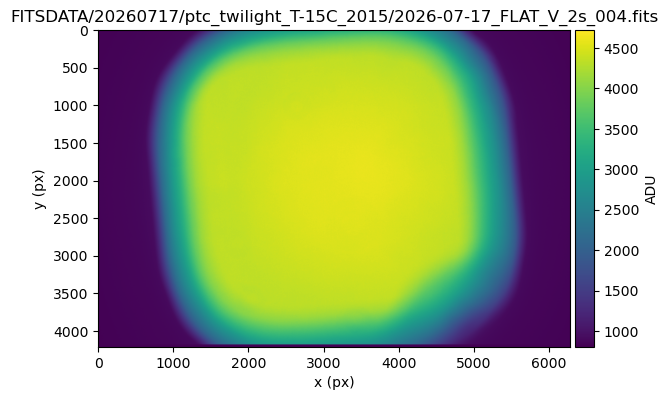

In [6]:
ct.quick_view(ptc_cover_files[('FLAT', 2.0)][-1])

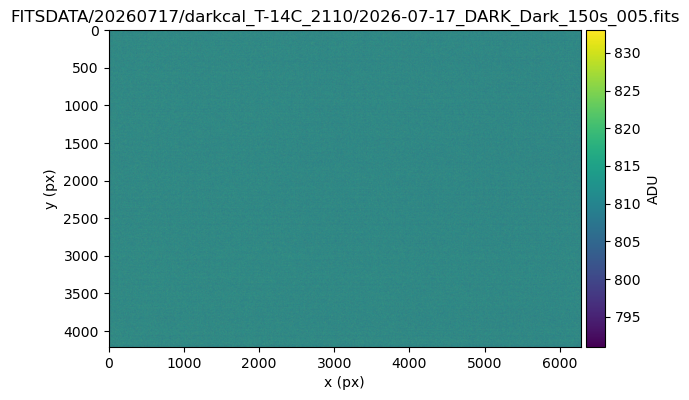

In [7]:
ct.quick_view(darkcal_files['-14'][('DARK', 150.0)][-1])

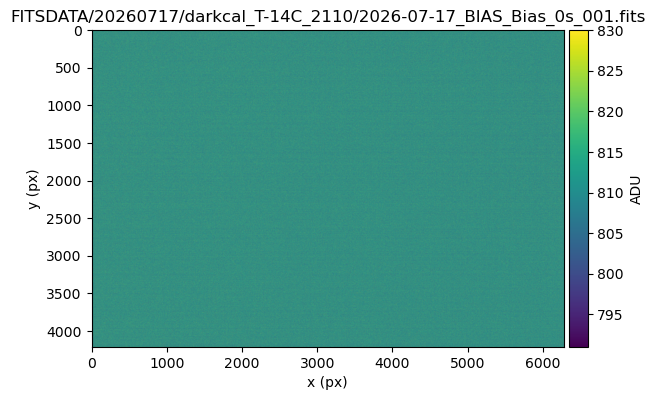

In [8]:
ct.quick_view(main_bias_files[0])

# 1. Read noise (bias frame differencing)
$\sigma_\mathrm{read}=\sigma(B_{i+1}-B_i)/\sqrt2$ — removes fixed pattern, leaves temporal noise.

In [9]:
"""
LONG RUNTIME CELL, ETA 2 min
"""
master_bias = ct.master_bias(main_bias_files, method='median', roi=roi)
read_noise_map_adu, temporal_std_map = ct.read_noise_map_from_paths(main_bias_files, roi=roi, chunk_rows=50)
rn_result = ct.read_noise_spatial(read_noise_map_adu, sconfig)
s = rn_result.scalar_summary

gc.collect()   # free up memory

print(f"master bias: median {np.median(master_bias):.2f} ADU, mean {master_bias.mean():.2f}")
print(f"read noise:  {s['ron_rms_adu']:.3f} ADU RMS = {s['ron_rms_e']:.3f} e-, "
      f"median {s['ron_median_adu']:.3f} ADU, MAD-sigma {s['mad_sigma_adu']:.3f}")
print(f"hot px: >3sig {s['hot_3sig']:,}, >5sig {s['hot_5sig']:,}, >10sig {s['hot_10sig']:,}")

master bias: median 811.00 ADU, mean 810.61
read noise:  7.117 ADU RMS = 7.117 e-, median 6.525 ADU, MAD-sigma 1.242
hot px: >3sig 838,895, >5sig 436,412, >10sig 130,657


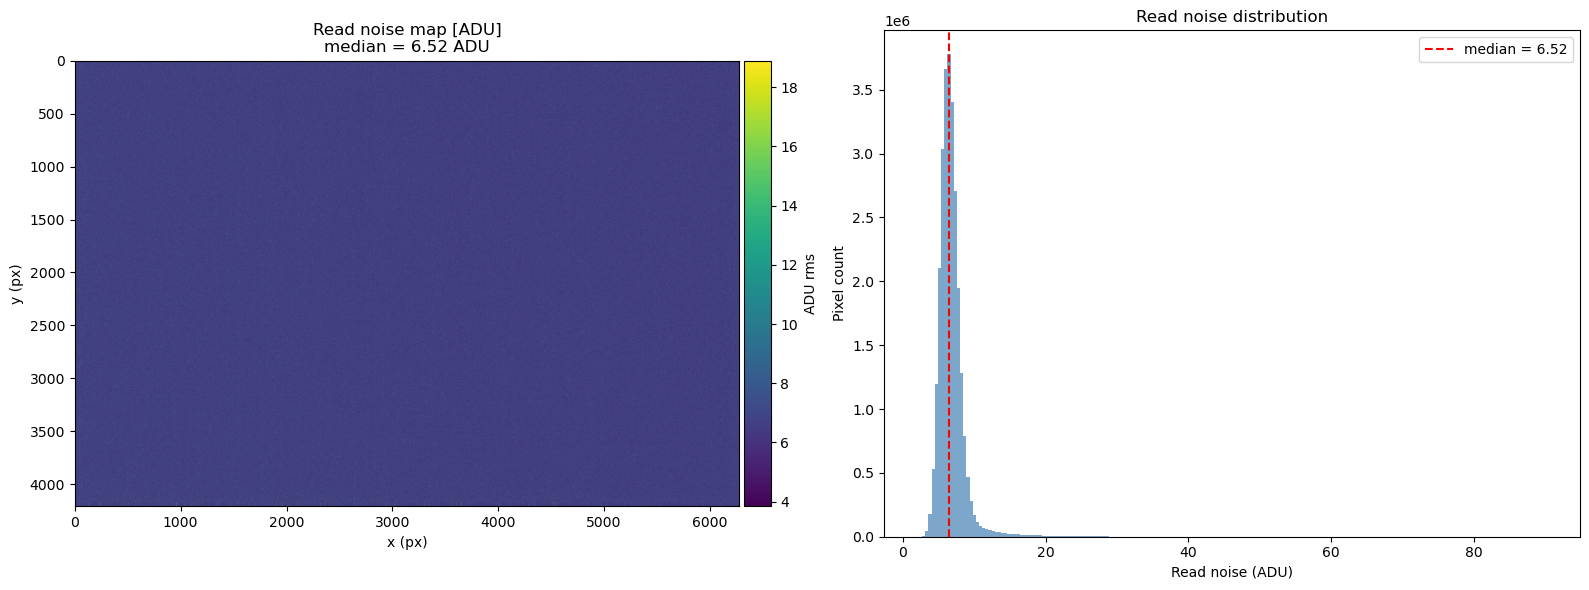

In [10]:
fig = plt.figure(figsize=(16, 6))
ct.noise_map_with_histogram(fig, read_noise_map_adu, label='Read noise', unit='ADU')
plt.savefig('tmpimg/0717_read_noise_map.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
b0 = ct.load_frame(darkcal_files['-14'][('DARK', 5.0)][-1])[:, :-4]
print("min     max      mean      std")
print(b0.min(), b0.max(), b0.mean(), b0.std())
print("0.1,   1,   5,   10,  25,  50,  75,  90,  95,  99,  99.9   percentiles")
print(np.percentile(b0, [0.1, 1, 5, 10, 25, 50, 75, 90, 95, 99, 99.9]))


min     max      mean      std
697.0 34313.0 810.6464 12.637598
0.1,   1,   5,   10,  25,  50,  75,  90,  95,  99,  99.9   percentiles
[780. 794. 799. 802. 806. 811. 815. 819. 822. 827. 846.]


# 2. Bias / offset structure

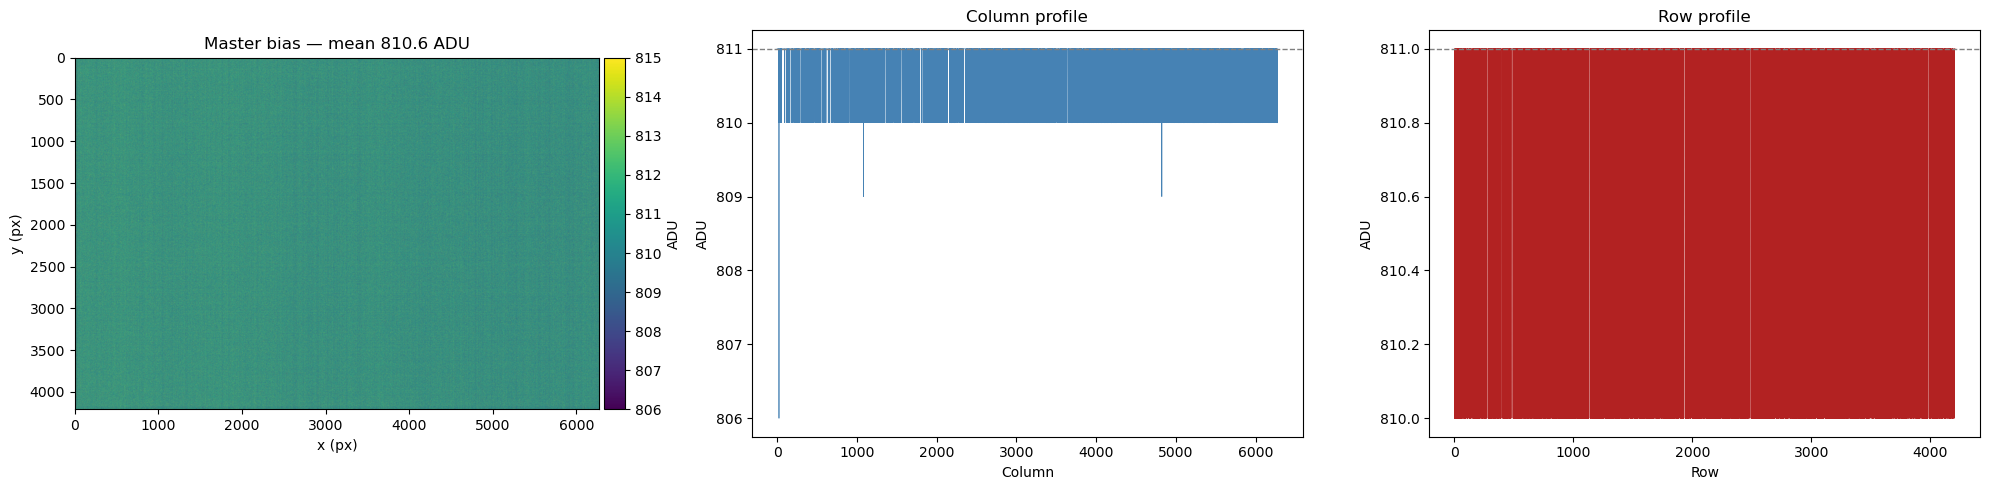

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
ct.image_with_colorbar(axes[0], master_bias, label='ADU', percentile_clip=(1, 99))
axes[0].set_title(f'Master bias — mean {master_bias.mean():.1f} ADU')
axes[1].plot(np.median(master_bias, axis=0), lw=0.5, color='steelblue')
axes[1].axhline(np.median(master_bias), ls='--', color='gray', lw=1)
axes[1].set_xlabel('Column'); axes[1].set_ylabel('ADU'); axes[1].set_title('Column profile')
axes[2].plot(np.median(master_bias, axis=1), lw=0.5, color='firebrick')
axes[2].axhline(np.median(master_bias), ls='--', color='gray', lw=1)
axes[2].set_xlabel('Row'); axes[2].set_ylabel('ADU'); axes[2].set_title('Row profile')
plt.tight_layout(); plt.savefig('tmpimg/0717_bias_structure.png', dpi=300, bbox_inches='tight'); plt.show()

### Bias temporal stability

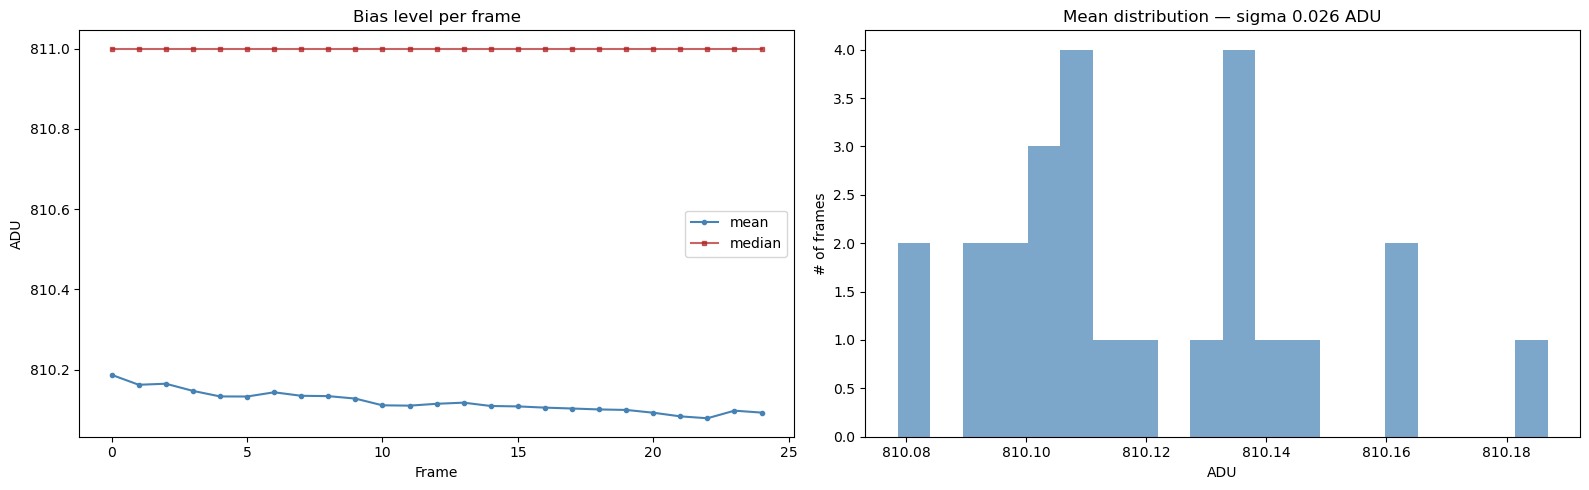

bias mean range 810.08 - 810.19 ADU, sigma 0.0262, MAD-sigma 0.0270


In [13]:
fmean = np.array([float(np.mean(ct.load_frame(f))) for f in main_bias_files])
fmed  = np.array([float(np.median(ct.load_frame(f))) for f in main_bias_files])
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(fmean, 'o-', ms=3, color='steelblue', label='mean')
axes[0].plot(fmed, 's-', ms=3, color='firebrick', alpha=0.7, label='median')
axes[0].set_xlabel('Frame'); axes[0].set_ylabel('ADU'); axes[0].set_title('Bias level per frame'); axes[0].legend()
axes[1].hist(fmean, bins=20, color='steelblue', alpha=0.7)
axes[1].set_xlabel('ADU'); axes[1].set_ylabel('# of frames')
axes[1].set_title(f'Mean distribution — sigma {np.std(fmean):.3f} ADU')
plt.tight_layout(); plt.savefig('tmpimg/0709_bias_stability.png', dpi=150, bbox_inches='tight'); plt.show()
print(f'bias mean range {fmean.min():.2f} - {fmean.max():.2f} ADU, sigma {np.std(fmean):.4f}, MAD-sigma {ct.mad_sigma(fmean):.4f}')

# 4. PTC

In [14]:
PTCDIR = dir_prefix + subdir_prefixes[-2]
ptc_file_groups = ct.group_by_type_and_exposure(sorted(glob.glob(PTCDIR + '/*.fits')))
ptc_bias_files = ptc_file_groups[('BIAS', 0.0)][:-2]   # exclude unity test
ptc_flat_files = {
    0.1: ptc_file_groups[('FLAT', 0.1)],
    0.2: ptc_file_groups[('FLAT', 0.2)],
    0.5: ptc_file_groups[('FLAT', 0.5)],
    1.0: ptc_file_groups[('FLAT', 1.0)],
    2.0: ptc_file_groups[('FLAT', 2.0)],
    4.0: ptc_file_groups[('FLAT', 4.0)][:-2],   # exclude unity test
    8.0: ptc_file_groups[('FLAT', 8.0)],
}
print(f"PTC bias files: {len(ptc_bias_files)}")
print("PTC flat files:")
for exp, flist in sorted(ptc_flat_files.items()):
    print(f"  {exp:6.2f}s  x{len(flist)}")

PTC bias files: 10
PTC flat files:
    0.10s  x4
    0.20s  x4
    0.50s  x4
    1.00s  x4
    2.00s  x4
    4.00s  x4
    8.00s  x4


## Bias

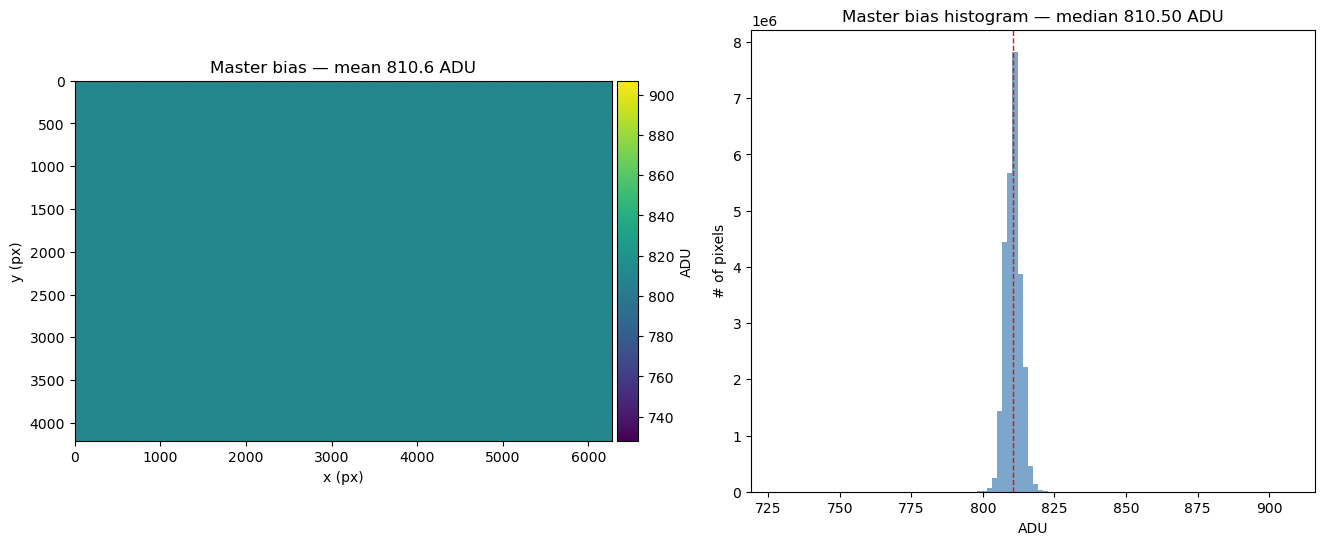

In [15]:
ptc_master_bias = ct.master_bias(ptc_bias_files, method='median', roi=roi)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ct.image_with_colorbar(axes[0], ptc_master_bias, label='ADU', percentile_clip=(0, 100))
axes[0].set_title(f'Master bias — mean {ptc_master_bias.mean():.1f} ADU')

axes[1].hist(ptc_master_bias.ravel(), bins=100, color='steelblue', alpha=0.7)
axes[1].set_xlabel('ADU'); axes[1].set_ylabel('# of pixels')
axes[1].set_title(f'Master bias histogram — median {np.median(ptc_master_bias):.2f} ADU')
axes[1].axvline(np.median(ptc_master_bias), ls='--', color='red', lw=1, label='median')
plt.show()

## Calculations

In [16]:
analysis_result = ct.photon_transfer_curve(ptc_flat_files, ptc_master_bias, roi=roi)

md = analysis_result.metadata
ss = analysis_result.scalar_summary

fit = md['fit']
signal = md['signal']
variance = md['variance']
labels = md['labels']
mismatch = md['mismatch']
m, c, gain, sigma_g, cov = fit['slope'], fit['intercept'], fit['gain'], fit['gain_sigma'], md['covariance']
print(f"PTC fit: slope {m:.6f}, intercept {c:.3f}, gain {gain:.3f} e-/ADU, sigma_gain {sigma_g:.6f} e-/ADU")

ron_fit_adu = ss['ron_fit_adu']
signal_max_adu = ss['signal_max_adu']
print(f"RON fit (ADU): {ron_fit_adu:.3f} ADU, signal max (ADU): {signal_max_adu:.3f} ADU")
print(f"RON fit (e-): {ron_fit_adu * gain:.3f} e-")

PTC fit: slope 2.697987, intercept 33.096, gain 0.371 e-/ADU, sigma_gain 0.000016 e-/ADU
RON fit (ADU): 5.753 ADU, signal max (ADU): 7412.051 ADU
RON fit (e-): 2.132 e-


In [17]:
ptc_pair_rows = []
for i, (exptime, paths) in enumerate(sorted(ptc_flat_files.items())):
    
    for pair_start in range(0, len(paths), 2):
        idx = (i*len(paths) + pair_start)//2
        ptc_pair_rows.append(
            {
                "exptime_s": exptime,
                "pair": pair_start // 2 + 1,
                "signal_adu": signal[idx],
                "variance_adu2": variance[idx],
                "mismatch": mismatch[idx],
            }
        )

print(" exposure  pair   mean signal (ADU)  variance (ADU^2)  pair mismatch (%)")
for i, row in enumerate(ptc_pair_rows):
    print(
        f" {row['exptime_s']:7.1f}  {row['pair']:4d}  {row['signal_adu']:17.2f}  ",
        f"{row['variance_adu2']:17.2f}  {row['mismatch']:17.3f}"
    )

 exposure  pair   mean signal (ADU)  variance (ADU^2)  pair mismatch (%)
     0.1     1             142.15              450.72              1.143
     0.1     2             138.82              441.99              1.192
     0.2     1             271.39              765.05              1.205
     0.2     2             264.88              748.31              1.213
     0.5     1             643.67             1760.75              1.308
     0.5     2             627.06             1705.95              1.305
     1.0     1            1219.74             3284.77              1.545
     1.0     2            1183.33             3189.20              1.527
     2.0     1            2286.00             6239.93              1.895
     2.0     2            2200.34             5970.49              1.917
     4.0     1            4197.74            11355.37              2.695
     4.0     2            3976.66            10751.33              2.717
     8.0     1            7412.05            20038.

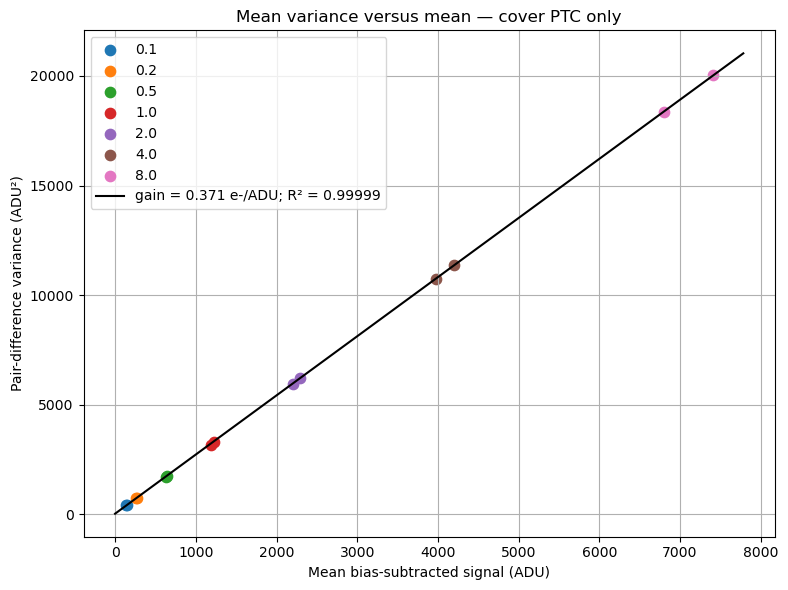

Maximum pair mismatch: 4.35%
PTC gain = 0.370647 ± 0.000016 e-/ADU (formal fit error)
PTC-intercept read noise = 5.753 ADU = 2.132 e-
Highest sampled pixel signal = 7412.1 ADU (2747 e- at this gain).


In [18]:
fig, ax = plt.subplots(figsize=(8, 6))
ct.ptc_plot(ax, analysis_result)
plt.show()

print(f"Maximum pair mismatch: {max(row['mismatch'] for row in ptc_pair_rows):.2f}%")
print(f"PTC gain = {gain:.6f} ± {sigma_g:.6f} e-/ADU (formal fit error)")
print(f"PTC-intercept read noise = {ron_fit_adu:.3f} ADU = {ron_fit_adu*gain:.3f} e-")
print(
    f"Highest sampled pixel signal = {signal.max():.1f} ADU "
    f"({signal.max()*gain:.0f} e- at this gain)."
)

In [19]:
print(alabaster)

NameError: name 'alabaster' is not defined

## Plotting

# Terra xHigh mimic attempt

This section starts after the original PTC heading and follows the organization of `astr150/lab1.ipynb`: designate frames, remove a master bias, calculate MOM/SDOM, then fit mean variance versus mean signal. It uses NumPy and Astropy rather than `caltools`.

**Scope:** the PTC analysis reads only `ptc_twilight_T-15C_2015`, the cover PTC set. The later `ptc_twilight_T-15C_2023` open-PTC directory is deliberately never read.

**ESTABLISHED:** this section reduces the available cover PTC and dark-calibration data without calling `caltools`. **OPEN:** the cover PTC does not reach saturation, so it cannot measure full well, linearity, or PRNU.

## 1. Setup and designated helper methods

The non-trivial Lab 1 operation is the variance of a flat pair. It is defined here before use. Pair differencing removes fixed pattern; the second image is rescaled to the first image's mean because twilight brightness changes slightly between consecutive frames.

In [ ]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits


def load_roi(path, roi):
    """Load a FITS frame as float64 and return the selected clean area."""
    with fits.open(path, memmap=False) as hdul:
        return hdul[0].data[roi].astype(np.float64)


def mom_and_sdom(values):
    """Return mean of means (MOM) and standard deviation of that mean (SDOM)."""
    values = np.asarray(values, dtype=float)
    mom = np.mean(values)
    sdom = np.std(values, ddof=1) / np.sqrt(values.size) if values.size > 1 else np.nan
    return mom, sdom


def pair_difference_variance(first, second):
    """Estimate one-frame variance from a normalized adjacent flat pair."""
    first_mean = np.mean(first)
    second_mean = np.mean(second)
    scale = first_mean / second_mean
    signal = 0.5 * (first_mean + second_mean)
    variance = np.var(first - scale * second, ddof=1) / (1.0 + scale**2)
    mismatch_percent = 100.0 * abs(first_mean - second_mean) / signal
    return signal, variance, scale, mismatch_percent

## 2. Cover PTC files and master bias

The directory is named explicitly instead of using a wide glob, ensuring that no open-PTC frame can enter the reduction. A central 1024 × 1024 clean area is used for every calculation, in the spirit of Lab 1's manually selected clean area.

Cover PTC directory: FITSDATA/20260717/ptc_twilight_T-15C_2015
Cover bias frames: 12
   0.1 s: 4 flat frames
   0.2 s: 4 flat frames
   0.5 s: 4 flat frames
   1.0 s: 4 flat frames
   2.0 s: 4 flat frames
   4.0 s: 6 flat frames
   8.0 s: 4 flat frames


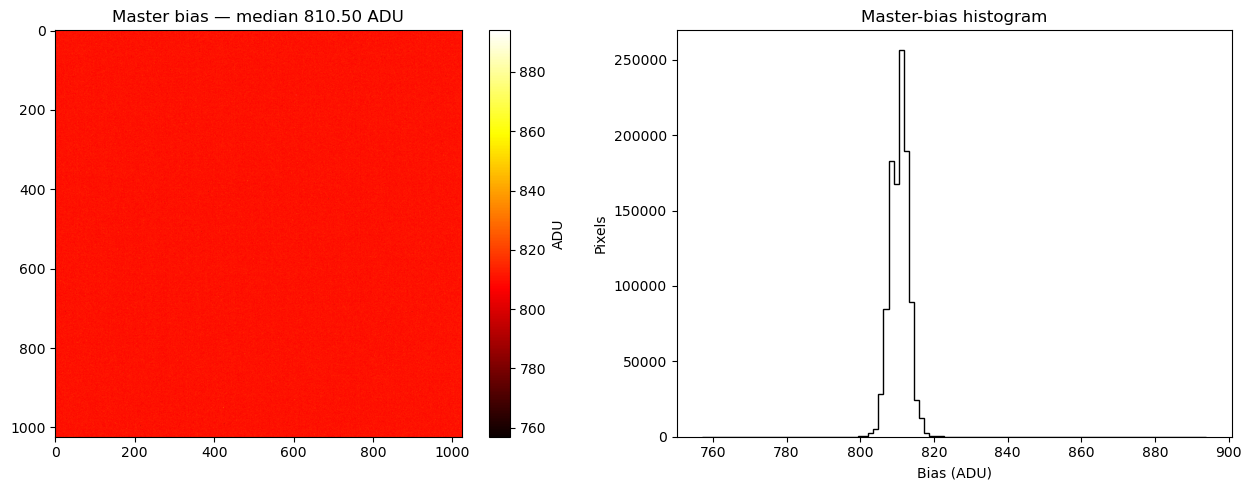

In [ ]:
PTC_COVER_DIR = Path(dir_prefix) / "ptc_twilight_T-15C_2015"
assert PTC_COVER_DIR.is_dir(), f"Missing cover PTC directory: {PTC_COVER_DIR}"
assert "2023" not in PTC_COVER_DIR.name, "Open PTC data are forbidden here."

ptc_bias_paths = []
ptc_flat_groups = {}

for path in sorted(PTC_COVER_DIR.glob("*.fits")):
    header = fits.getheader(path)
    if header.get("IMAGETYP") == "BIAS":
        ptc_bias_paths.append(path)
    elif header.get("IMAGETYP") == "FLAT":
        ptc_flat_groups.setdefault(float(header["EXPTIME"]), []).append(path)

assert len(ptc_bias_paths) >= 2
assert all(len(paths) >= 2 and len(paths) % 2 == 0 for paths in ptc_flat_groups.values())

analysis_roi = np.s_[1600:2624, 2628:3652]
ptc_master_bias = np.median(
    np.stack([load_roi(path, analysis_roi) for path in ptc_bias_paths]),
    axis=0,
)

print("Cover PTC directory:", PTC_COVER_DIR)
print("Cover bias frames:", len(ptc_bias_paths))
for exptime, paths in sorted(ptc_flat_groups.items()):
    print(f"  {exptime:4.1f} s: {len(paths)} flat frames")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
image = axes[0].imshow(ptc_master_bias, origin="upper", cmap="hot")
fig.colorbar(image, ax=axes[0], label="ADU")
axes[0].set_title(f"Master bias — median {np.median(ptc_master_bias):.2f} ADU")
axes[1].hist(ptc_master_bias.ravel(), bins=100, histtype="step", color="black")
axes[1].set_xlabel("Bias (ADU)")
axes[1].set_ylabel("Pixels")
axes[1].set_title("Master-bias histogram")
plt.tight_layout()
plt.show()

## 3. Flat-frame MOMs and SDOMs

For each exposure, MOM is the mean of the individual bias-subtracted frame means. SDOM is σ / √N. Dividing the MOM by exposure time provides the Lab 1-style twilight-rate check.

 exposure    N       MOM (ADU)       SDOM (ADU)    MOM/exptime (ADU/s)
     0.1    4          242.47             1.83              2424.72
     0.2    4          460.63             3.58              2303.13
     0.5    4         1091.18             9.26              2182.37
     1.0    4         2063.78            20.19              2063.78
     2.0    4         3853.20            47.58              1926.60
     4.0    6         8109.65           695.61              2027.41
     8.0    4        12199.95           339.81              1524.99


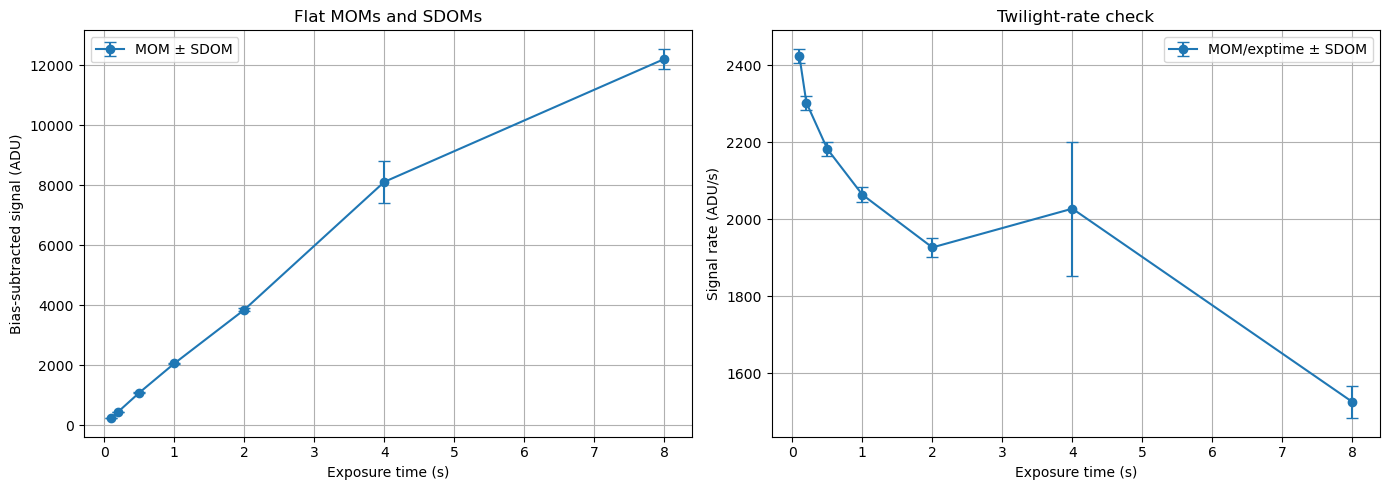

In [ ]:
flat_measurements = []
ptc_mom_rows = []

for exptime, paths in sorted(ptc_flat_groups.items()):
    frame_means = []

    for path in paths:
        flat = load_roi(path, analysis_roi) - ptc_master_bias
        frame_mean = float(np.mean(flat))
        frame_means.append(frame_mean)
        flat_measurements.append(
            {
                "path": path,
                "exptime_s": exptime,
                "mean_adu": frame_mean,
                "max_signal_adu": float(np.max(flat)),
            }
        )

    mom_adu, sdom_adu = mom_and_sdom(frame_means)
    ptc_mom_rows.append(
        {
            "exptime_s": exptime,
            "n_frames": len(frame_means),
            "mom_adu": mom_adu,
            "sdom_adu": sdom_adu,
            "mom_rate_adu_s": mom_adu / exptime,
            "sdom_rate_adu_s": sdom_adu / exptime,
        }
    )

print(" exposure    N       MOM (ADU)       SDOM (ADU)    MOM/exptime (ADU/s)")
for row in ptc_mom_rows:
    print(
        f" {row['exptime_s']:7.1f}  {row['n_frames']:3d}  "
        f"{row['mom_adu']:14.2f}  {row['sdom_adu']:15.2f}  "
        f"{row['mom_rate_adu_s']:19.2f}"
    )

exposures = np.array([row["exptime_s"] for row in ptc_mom_rows])
moms = np.array([row["mom_adu"] for row in ptc_mom_rows])
sdoms = np.array([row["sdom_adu"] for row in ptc_mom_rows])
mom_rates = np.array([row["mom_rate_adu_s"] for row in ptc_mom_rows])
sdom_rates = np.array([row["sdom_rate_adu_s"] for row in ptc_mom_rows])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].errorbar(exposures, moms, yerr=sdoms, fmt="o-", capsize=4, label="MOM ± SDOM")
axes[0].set(xlabel="Exposure time (s)", ylabel="Bias-subtracted signal (ADU)", title="Flat MOMs and SDOMs")
axes[0].grid()
axes[0].legend()

axes[1].errorbar(exposures, mom_rates, yerr=sdom_rates, fmt="o-", capsize=4, label="MOM/exptime ± SDOM")
axes[1].set(xlabel="Exposure time (s)", ylabel="Signal rate (ADU/s)", title="Twilight-rate check")
axes[1].grid()
axes[1].legend()
plt.tight_layout()
plt.show()

## 4. PTC: mean variance versus mean

Adjacent pairs at each exposure provide the PTC points. The scaled pair difference removes fixed-pattern structure while retaining photon and read noise. The printed mismatch checks whether the changing twilight is small enough for each pair.

In [ ]:

for i in range(0, 10, 2):
    print(i)

0
2
4
6
8


 exposure  pair   mean signal (ADU)  variance (ADU^2)  pair mismatch (%)
     0.1     1             245.32             737.87              1.117
     0.1     2             239.63             724.27              1.207
     0.2     1             466.18            1260.28              1.183
     0.2     2             455.07            1232.67              1.212
     0.5     1            1105.51            3035.66              1.323
     0.5     2            1076.86            2919.05              1.322
     1.0     1            2094.96            5633.63              1.552
     1.0     2            2032.61            5392.14              1.520
     2.0     1            3926.94           10613.71              1.886
     2.0     2            3779.47           10409.61              1.936
     4.0     1            7207.78           19466.22              2.686
     4.0     2            6828.41           18478.92              2.727
     4.0     3           10292.77           27949.89           

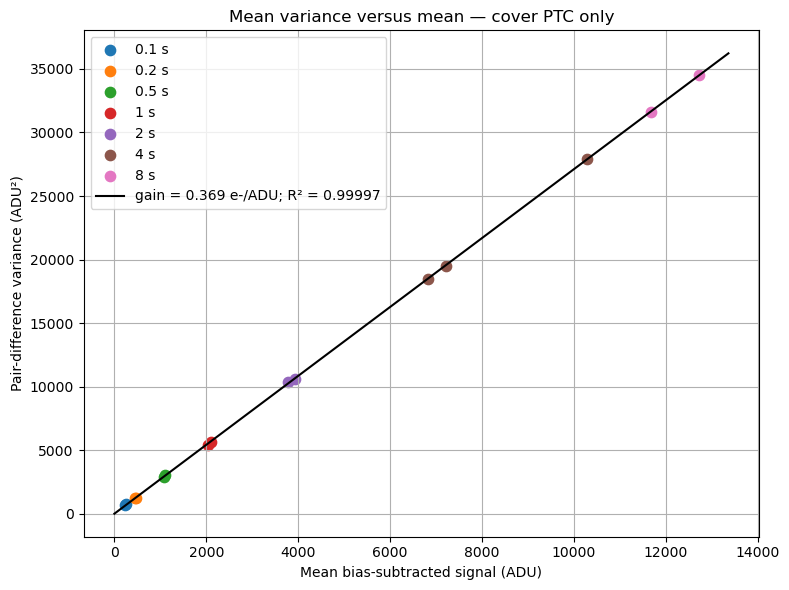

Maximum pair mismatch: 4.34%
PTC gain = 0.3690 ± 0.0006 e-/ADU (formal fit error)
PTC-intercept read noise = 3.336 ADU = 1.231 e-
Highest sampled pixel signal = 23160.5 ADU (8546 e- at this gain).
OPEN: no saturation or PTC turnover; this is only a full-well lower limit.


In [ ]:
ptc_pair_rows = []

for exptime, paths in sorted(ptc_flat_groups.items()):
    flats = [load_roi(path, analysis_roi) - ptc_master_bias for path in paths]

    for pair_start in range(0, len(flats), 2):
        signal, variance, scale, mismatch = pair_difference_variance(
            flats[pair_start],
            flats[pair_start + 1],
        )
        ptc_pair_rows.append(
            {
                "exptime_s": exptime,
                "pair": pair_start // 2 + 1,
                "signal_adu": signal,
                "variance_adu2": variance,
                "scale": scale,
                "mismatch_percent": mismatch,
            }
        )

print(" exposure  pair   mean signal (ADU)  variance (ADU^2)  pair mismatch (%)")
for row in ptc_pair_rows:
    print(
        f" {row['exptime_s']:7.1f}  {row['pair']:4d}  {row['signal_adu']:17.2f}  "
        f"{row['variance_adu2']:17.2f}  {row['mismatch_percent']:17.3f}"
    )

ptc_signal = np.array([row["signal_adu"] for row in ptc_pair_rows])
ptc_variance = np.array([row["variance_adu2"] for row in ptc_pair_rows])
(ptc_slope, ptc_intercept), ptc_cov = np.polyfit(ptc_signal, ptc_variance, 1, cov=True)
ptc_gain_e_per_adu = 1.0 / ptc_slope
ptc_gain_error_e_per_adu = np.sqrt(ptc_cov[0, 0]) / ptc_slope**2
ptc_ron_fit_adu = np.sqrt(ptc_intercept) if ptc_intercept > 0 else np.nan
ptc_ron_fit_e = ptc_ron_fit_adu * ptc_gain_e_per_adu
ptc_fit = np.polyval((ptc_slope, ptc_intercept), ptc_signal)
ptc_r_squared = 1.0 - np.sum((ptc_variance - ptc_fit)**2) / np.sum(
    (ptc_variance - np.mean(ptc_variance))**2
)

x_fit = np.linspace(0.0, ptc_signal.max() * 1.05, 200)
fig, ax = plt.subplots(figsize=(8, 6))
for exptime in sorted({row["exptime_s"] for row in ptc_pair_rows}):
    use = np.array([row["exptime_s"] == exptime for row in ptc_pair_rows])
    ax.scatter(ptc_signal[use], ptc_variance[use], s=55, label=f"{exptime:g} s")
ax.plot(
    x_fit,
    np.polyval((ptc_slope, ptc_intercept), x_fit),
    color="black",
    label=f"gain = {ptc_gain_e_per_adu:.3f} e-/ADU; R² = {ptc_r_squared:.5f}",
)
ax.set(
    xlabel="Mean bias-subtracted signal (ADU)",
    ylabel="Pair-difference variance (ADU²)",
    title="Mean variance versus mean — cover PTC only",
)
ax.grid()
ax.legend()
plt.tight_layout()
plt.show()

ptc_max_signal_adu = max(row["max_signal_adu"] for row in flat_measurements)
ptc_full_well_lower_limit_e = ptc_max_signal_adu * ptc_gain_e_per_adu
print(f"Maximum pair mismatch: {max(row['mismatch_percent'] for row in ptc_pair_rows):.2f}%")
print(f"PTC gain = {ptc_gain_e_per_adu:.4f} ± {ptc_gain_error_e_per_adu:.4f} e-/ADU (formal fit error)")
print(f"PTC-intercept read noise = {ptc_ron_fit_adu:.3f} ADU = {ptc_ron_fit_e:.3f} e-")
print(
    f"Highest sampled pixel signal = {ptc_max_signal_adu:.1f} ADU "
    f"({ptc_full_well_lower_limit_e:.0f} e- at this gain)."
)
print("OPEN: no saturation or PTC turnover; this is only a full-well lower limit.")

## 5. Independent bias-pair read noise

This is the Lab 1 bias-pair calculation: σ_read = sqrt(var(B₁ − B₂) / 2). It is independent of the PTC-intercept estimate. **ESTABLISHED:** use this direct bias-pair value as the preferred read-noise measurement. **OPEN:** if it disagrees with the PTC intercept, the latter is only a diagnostic extrapolation of the cloudy-twilight fit.

In [ ]:
bias_frames = [load_roi(path, analysis_roi) for path in ptc_bias_paths]
bias_pair_variances = []

for pair_start in range(0, len(bias_frames) - 1, 2):
    difference = bias_frames[pair_start] - bias_frames[pair_start + 1]
    bias_pair_variances.append(0.5 * np.var(difference, ddof=1))

bias_variance_mom, bias_variance_sdom = mom_and_sdom(bias_pair_variances)
bias_ron_adu = np.sqrt(bias_variance_mom)
bias_ron_error_adu = bias_variance_sdom / (2.0 * bias_ron_adu)
bias_ron_e = bias_ron_adu * ptc_gain_e_per_adu

print(f"Bias-pair variance MOM = {bias_variance_mom:.3f} ± {bias_variance_sdom:.3f} ADU²")
print(f"Bias-pair read noise = {bias_ron_adu:.3f} ± {bias_ron_error_adu:.3f} ADU")
print(f"Bias-pair read noise = {bias_ron_e:.3f} e- using the cover-PTC gain")

Bias-pair variance MOM = 50.212 ± 0.072 ADU²
Bias-pair read noise = 7.086 ± 0.005 ADU
Bias-pair read noise = 2.615 e- using the cover-PTC gain


## 6. Dark current at the recorded CCD temperatures

Each temperature run gets a matching master bias. The code calculates the MOM and SDOM of repeated dark-frame means at 5, 60, and 150 s, then fits signal versus exposure time. FITS-header CCD-TEMP values—not requested setpoints—label the results. **CONJECTURED:** any doubling-temperature result requires review of the printed CCD-TEMP range, especially for a run that did not remain thermally stable.

In [ ]:
dark_results = []

for dark_dir in sorted(Path(dir_prefix).glob("darkcal_*")):
    bias_paths = []
    dark_paths_by_exptime = {}

    for path in sorted(dark_dir.glob("*.fits")):
        header = fits.getheader(path)
        if header.get("IMAGETYP") == "BIAS":
            bias_paths.append(path)
        elif header.get("IMAGETYP") == "DARK":
            dark_paths_by_exptime.setdefault(float(header["EXPTIME"]), []).append(path)

    master_bias = np.median(
        np.stack([load_roi(path, analysis_roi) for path in bias_paths]),
        axis=0,
    )
    exptimes = np.array(sorted(dark_paths_by_exptime))
    signal_moms = []
    signal_sdoms = []
    dark_temperatures = []

    for exptime in exptimes:
        frame_means = []
        for path in dark_paths_by_exptime[exptime]:
            frame_means.append(float(np.mean(load_roi(path, analysis_roi) - master_bias)))
            dark_temperatures.append(float(fits.getheader(path)["CCD-TEMP"]))
        mom, sdom = mom_and_sdom(frame_means)
        signal_moms.append(mom)
        signal_sdoms.append(sdom)

    signal_moms = np.array(signal_moms)
    signal_sdoms = np.array(signal_sdoms)
    (rate, offset), covariance = np.polyfit(
        exptimes,
        signal_moms,
        1,
        w=1.0 / np.maximum(signal_sdoms, 1.0e-8),
        cov=True,
    )
    dark_results.append(
        {
            "label": dark_dir.name,
            "exptimes_s": exptimes,
            "moms_adu": signal_moms,
            "sdoms_adu": signal_sdoms,
            "temperature_c": float(np.median(dark_temperatures)),
            "temperature_range_c": (float(np.min(dark_temperatures)), float(np.max(dark_temperatures))),
            "rate_adu_s": float(rate),
            "rate_error_adu_s": float(np.sqrt(covariance[0, 0])),
            "offset_adu": float(offset),
            "master_bias": master_bias,
            "paths_by_exptime": dark_paths_by_exptime,
        }
    )

print("dark run                 CCD-TEMP range (C)       rate (ADU/pix/s)")
for row in dark_results:
    lo, hi = row["temperature_range_c"]
    print(
        f"{row['label']:22s}  {lo:6.2f} to {hi:6.2f}       "
        f"{row['rate_adu_s']:.6f} ± {row['rate_error_adu_s']:.6f}"
    )

dark run                 CCD-TEMP range (C)       rate (ADU/pix/s)
darkcal_T+0C_1932        -0.20 to   0.00       0.014413 ± 0.001161
darkcal_T-10C_2039      -10.30 to  -9.90       0.004840 ± 0.000304
darkcal_T-14C_2110      -14.20 to -12.20       0.004162 ± 0.000744


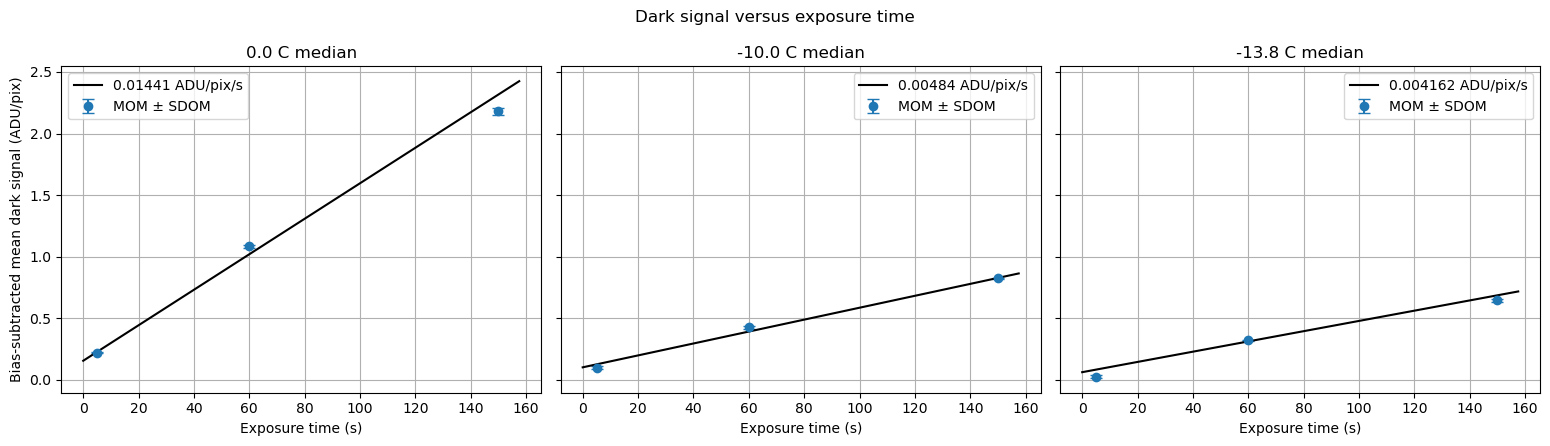

CONJECTURED doubling temperature: 7.38 ± 1.18 C


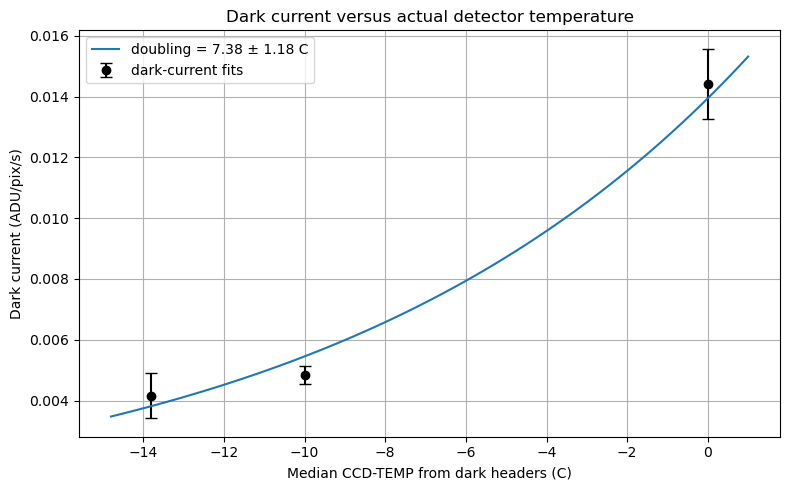

In [ ]:
fig, axes = plt.subplots(1, len(dark_results), figsize=(5.2 * len(dark_results), 4.5), sharey=True)

for ax, row in zip(np.atleast_1d(axes), dark_results):
    x = row["exptimes_s"]
    y = row["moms_adu"]
    fit_x = np.linspace(0.0, x.max() * 1.05, 100)
    ax.errorbar(x, y, yerr=row["sdoms_adu"], fmt="o", capsize=4, label="MOM ± SDOM")
    ax.plot(fit_x, row["rate_adu_s"] * fit_x + row["offset_adu"], color="black", label=f"{row['rate_adu_s']:.4g} ADU/pix/s")
    ax.set(xlabel="Exposure time (s)", title=f"{row['temperature_c']:.1f} C median")
    ax.grid()
    ax.legend()

axes[0].set_ylabel("Bias-subtracted mean dark signal (ADU/pix)")
fig.suptitle("Dark signal versus exposure time")
plt.tight_layout()
plt.show()

dark_temperatures_c = np.array([row["temperature_c"] for row in dark_results])
dark_rates_adu_s = np.array([row["rate_adu_s"] for row in dark_results])
dark_rate_errors_adu_s = np.array([row["rate_error_adu_s"] for row in dark_results])
rate_detected = dark_rates_adu_s > 3.0 * dark_rate_errors_adu_s
temperature_doubling_c = np.nan
temperature_doubling_error_c = np.nan

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(dark_temperatures_c, dark_rates_adu_s, yerr=dark_rate_errors_adu_s, fmt="o", capsize=4, color="black", label="dark-current fits")
if np.all(rate_detected):
    (log2_slope, log2_intercept), log2_covariance = np.polyfit(
        dark_temperatures_c,
        np.log2(dark_rates_adu_s),
        1,
        cov=True,
    )
    if log2_slope > 0:
        temperature_doubling_c = 1.0 / log2_slope
        temperature_doubling_error_c = np.sqrt(log2_covariance[0, 0]) / log2_slope**2
        temperature = np.linspace(dark_temperatures_c.min() - 1.0, dark_temperatures_c.max() + 1.0, 100)
        ax.plot(temperature, 2.0 ** (log2_slope * temperature + log2_intercept), label=f"doubling = {temperature_doubling_c:.2f} ± {temperature_doubling_error_c:.2f} C")
        print(f"CONJECTURED doubling temperature: {temperature_doubling_c:.2f} ± {temperature_doubling_error_c:.2f} C")
    else:
        print("OPEN: dark-current temperature slope is not positive.")
else:
    print("OPEN: not every dark-current slope is a 3σ detection; no doubling fit.")

ax.set(xlabel="Median CCD-TEMP from dark headers (C)", ylabel="Dark current (ADU/pix/s)", title="Dark current versus actual detector temperature")
ax.grid()
ax.legend()
plt.tight_layout()
plt.show()

## 7. Dark pattern, warm-pixel screening, and limits

The 150 s master dark from the coldest recorded run provides a central-ROI warm-pixel screen using a 5 × robust-MAD threshold. This is not a whole-detector hot-pixel census.

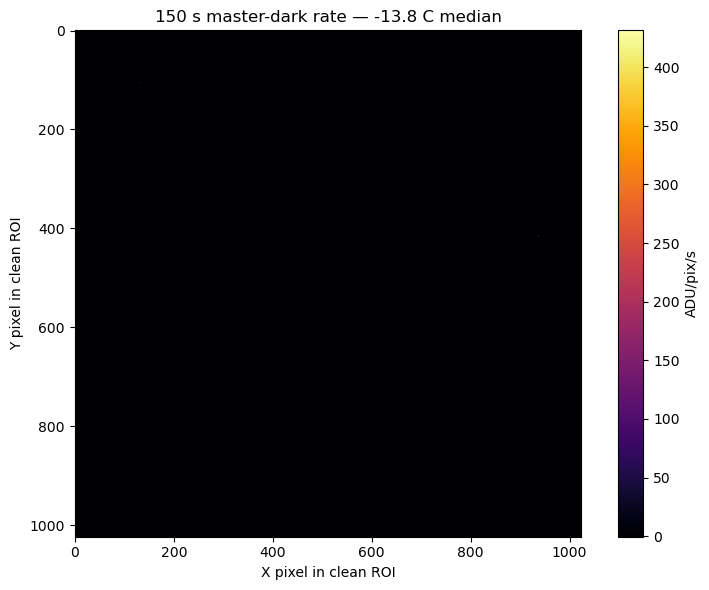

Terra xHigh mimic attempt — reduction summary
ESTABLISHED (cover PTC only)
  PTC gain: 0.3690 ± 0.0006 e-/ADU
  Bias-pair read noise: 7.086 ± 0.005 ADU = 2.615 e-
  dark current at 0.0 C: 0.014413 ± 0.001161 ADU/pix/s
  dark current at -10.0 C: 0.004840 ± 0.000304 ADU/pix/s
  dark current at -13.8 C: 0.004162 ± 0.000744 ADU/pix/s
  central-ROI warm-pixel fraction: 0.1884%
CONJECTURED doubling temperature: 7.38 ± 1.18 C
OPEN
  Full well is not measured; highest cover-PTC signal = 23160.5 ADU (8546 e- lower limit).
  Linearity and PRNU are not measured because clouds/twilight changed the illumination.
  The warm-pixel result is a central-ROI screen, not a whole-detector census.


In [ ]:
coldest_dark = min(dark_results, key=lambda row: row["temperature_c"])
longest_exptime = max(coldest_dark["paths_by_exptime"])
master_long_dark = np.median(
    np.stack(
        [
            load_roi(path, analysis_roi) - coldest_dark["master_bias"]
            for path in coldest_dark["paths_by_exptime"][longest_exptime]
        ]
    ),
    axis=0,
)
dark_rate_map_adu_s = master_long_dark / longest_exptime
dark_rate_median = np.median(dark_rate_map_adu_s)
dark_rate_mad_sigma = 1.4826 * np.median(np.abs(dark_rate_map_adu_s - dark_rate_median))
warm_threshold_adu_s = dark_rate_median + 5.0 * dark_rate_mad_sigma
warm_fraction = np.mean(dark_rate_map_adu_s > warm_threshold_adu_s)

fig, ax = plt.subplots(figsize=(8, 6))
image = ax.imshow(dark_rate_map_adu_s, origin="upper", cmap="inferno")
fig.colorbar(image, ax=ax, label="ADU/pix/s")
ax.set(
    xlabel="X pixel in clean ROI",
    ylabel="Y pixel in clean ROI",
    title=f"{longest_exptime:g} s master-dark rate — {coldest_dark['temperature_c']:.1f} C median",
)
plt.tight_layout()
plt.show()

print("Terra xHigh mimic attempt — reduction summary")
print("=" * 65)
print("ESTABLISHED (cover PTC only)")
print(f"  PTC gain: {ptc_gain_e_per_adu:.4f} ± {ptc_gain_error_e_per_adu:.4f} e-/ADU")
print(f"  Bias-pair read noise: {bias_ron_adu:.3f} ± {bias_ron_error_adu:.3f} ADU = {bias_ron_e:.3f} e-")
for row in dark_results:
    print(f"  dark current at {row['temperature_c']:.1f} C: {row['rate_adu_s']:.6f} ± {row['rate_error_adu_s']:.6f} ADU/pix/s")
print(f"  central-ROI warm-pixel fraction: {100.0 * warm_fraction:.4f}%")
if np.isfinite(temperature_doubling_c):
    print(f"CONJECTURED doubling temperature: {temperature_doubling_c:.2f} ± {temperature_doubling_error_c:.2f} C")
print("OPEN")
print(f"  Full well is not measured; highest cover-PTC signal = {ptc_max_signal_adu:.1f} ADU ({ptc_full_well_lower_limit_e:.0f} e- lower limit).")
print("  Linearity and PRNU are not measured because clouds/twilight changed the illumination.")
print("  The warm-pixel result is a central-ROI screen, not a whole-detector census.")

## Archived draft below — do not run

These cells were present after the original PTC heading but were not part of the user's reduction. They are retained only as notebook history. The Terra xHigh mimic attempt above supersedes them; its code is the active no-caltools reduction.

### Dark glow + warm pixels

## 8. DSNU & fixed-pattern noise

## 9. Thermal & timing stability
DATE-OBS is corrupt (year 1996) on many frames — the pre-fix GPS-header misparse on
this GPS-less camera. Timing cadence is reported only for frames with a sane 2026
timestamp; CCD-TEMP is unaffected.

## Summary